# Building a RAG Application
**Module 3: GenAI & Agents | ~90 min**

- Python integration
- Injecting context into prompts
- Streamlit UI build

Builds directly on last session's retrieval pipeline (TF-IDF + cosine similarity).


In [ ]:
!pip install scikit-learn openai streamlit --quiet


## Recap: the retrieval index (from last session)


In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = [
    "Masai School trains students in full stack web development and AI/ML.",
    "The IIT Patna AI/ML program covers Python, data science, and deep learning.",
    "Cricket is a popular sport played between two teams of eleven players.",
    "Retrieval-augmented generation combines a search step with a language model.",
]

vectorizer = TfidfVectorizer()
doc_vectors = vectorizer.fit_transform(documents)

def retrieve(query, top_k=2):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, doc_vectors)[0]
    ranked = sorted(range(len(documents)), key=lambda i: scores[i], reverse=True)
    return [(documents[i], scores[i]) for i in ranked[:top_k]]

results = retrieve("What does Masai School teach about machine learning?")
for doc, score in results:
    print(f"{score:.3f}  {doc}")


0.350  Masai School trains students in full stack web development and AI/ML.
0.168  The IIT Patna AI/ML program covers Python, data science, and deep learning.


## 1. Python Integration

One function chains everything: retrieve → build the prompt → call the model → return the answer with its sources.

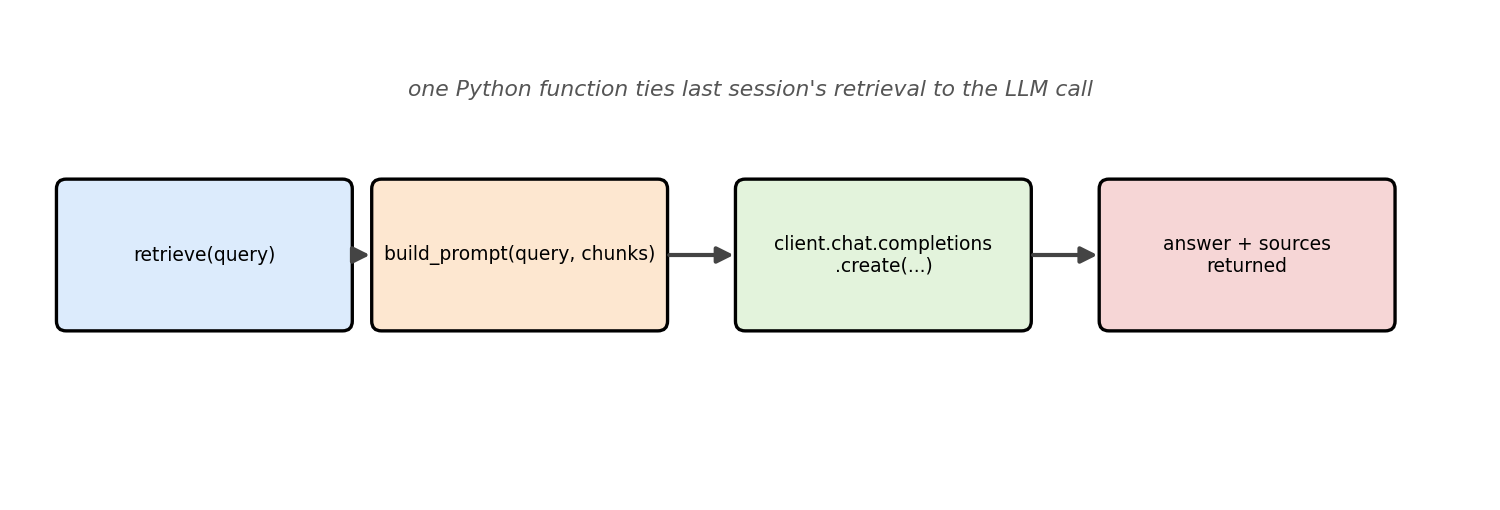


In [ ]:
from openai import OpenAI
from getpass import getpass

api_key = getpass("Enter your OpenRouter API key: ")
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)
MODEL = "deepseek/deepseek-v4-flash-0731:free"


## 2. Injecting Context into Prompts

- Label each retrieved chunk (`[Source 1]`, `[Source 2]`) so the model can cite it
- Instruct the model to answer **only** from context — this is what keeps RAG grounded instead of hallucinating

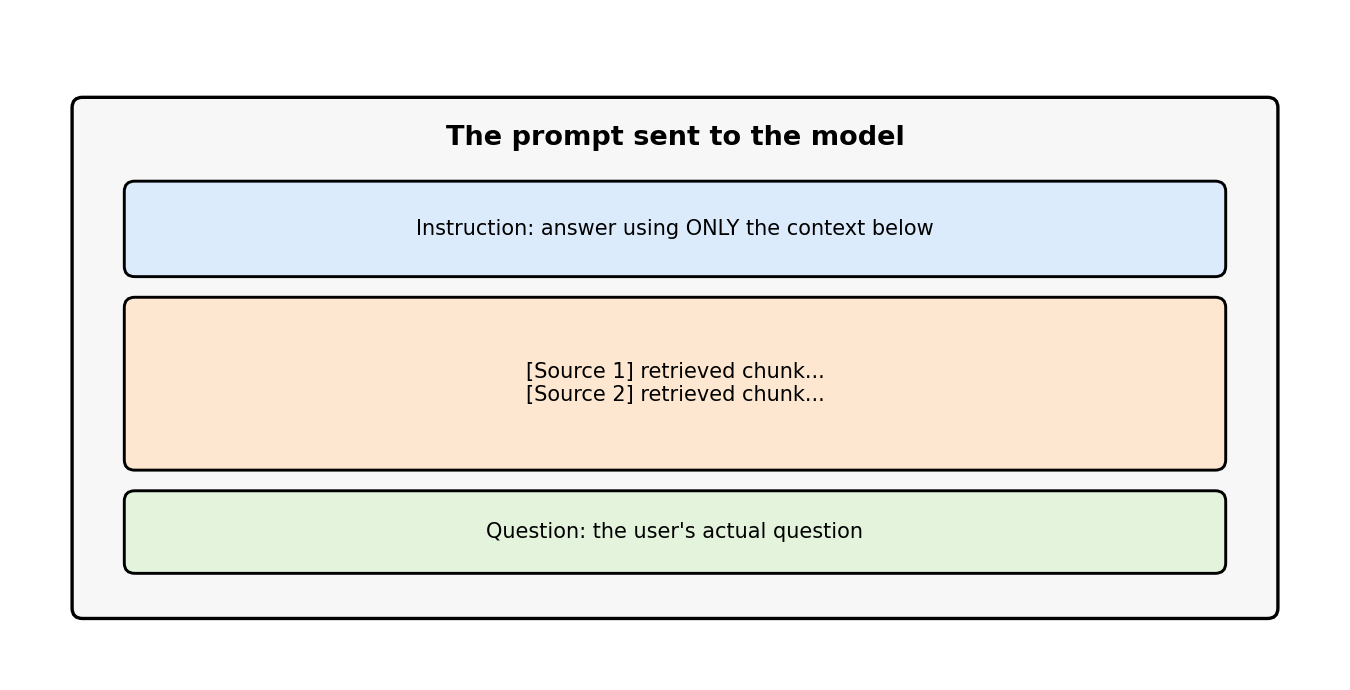


In [2]:
def build_prompt(query, retrieved):
    context_block = "\n".join(f"[Source {i+1}] {doc}" for i, (doc, score) in enumerate(retrieved))
    return f"""Answer the question using ONLY the context below. If the context doesn't contain the answer, say so.

Context:
{context_block}

Question: {query}

Answer (cite sources like [Source 1]):"""

prompt = build_prompt("What does Masai School teach about machine learning?", results)
print(prompt)


Answer the question using ONLY the context below. If the context doesn't contain the answer, say so.

Context:
[Source 1] Masai School trains students in full stack web development and AI/ML.
[Source 2] The IIT Patna AI/ML program covers Python, data science, and deep learning.

Question: What does Masai School teach about machine learning?

Answer (cite sources like [Source 1]):


In [3]:
def retrieve_and_answer(query, top_k=2):
    retrieved = retrieve(query, top_k=top_k)
    prompt = build_prompt(query, retrieved)
    response = client.chat.completions.create(model=MODEL, messages=[{"role": "user", "content": prompt}])
    return response.choices[0].message.content, retrieved

answer, sources = retrieve_and_answer("What does Masai School teach about machine learning?")
print("Answer:", answer)


Answer: Masai School teaches AI/ML as part of its full stack curriculum [Source 1].


## 3. Streamlit UI Build

Wrap the same retrieval + prompt + LLM call in a small web UI: a question box, an "Ask" button, an expander showing retrieved sources, and the final answer.

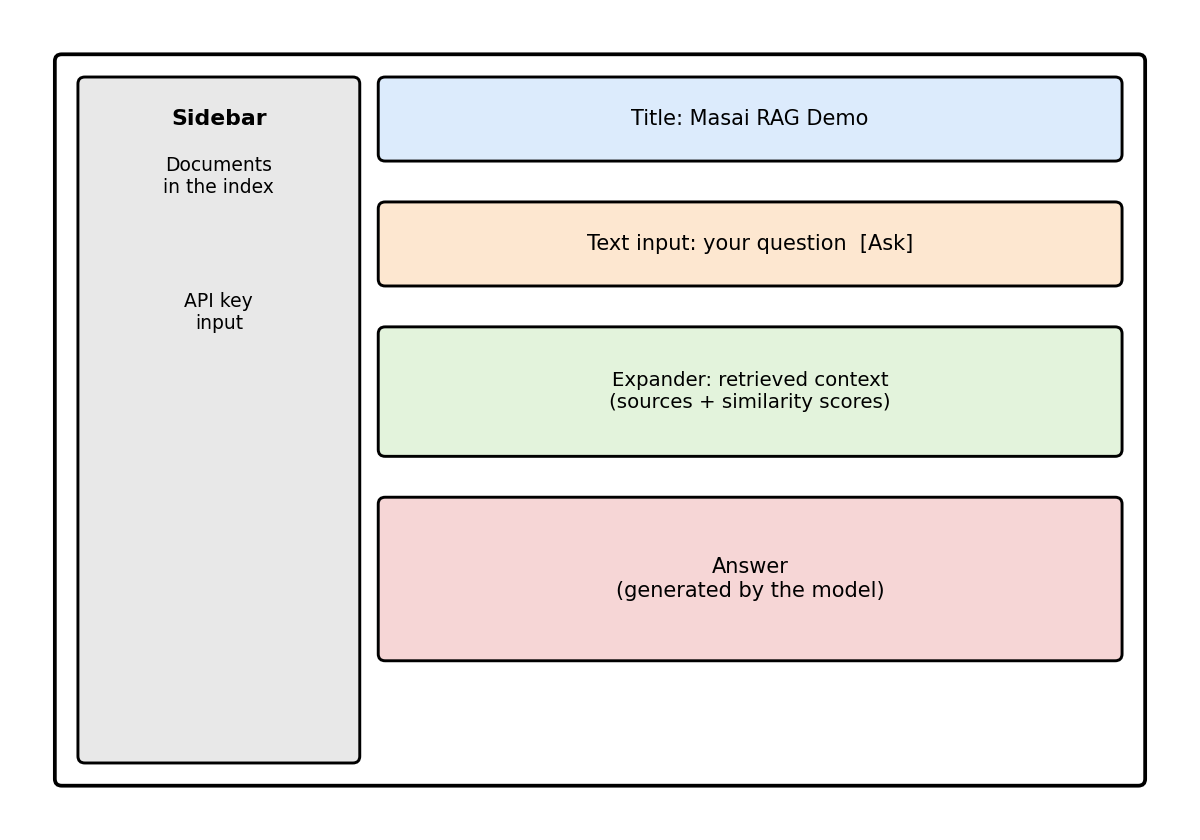


In [ ]:
%%writefile rag_app.py
import streamlit as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from openai import OpenAI

st.set_page_config(page_title="Masai RAG Demo", page_icon="📚")
st.title("📚 Masai RAG Demo")
st.caption("Ask a question, get an answer grounded in the documents below.")

documents = [
    "Masai School trains students in full stack web development and AI/ML.",
    "The IIT Patna AI/ML program covers Python, data science, and deep learning.",
    "Cricket is a popular sport played between two teams of eleven players.",
    "Retrieval-augmented generation combines a search step with a language model.",
]

@st.cache_resource
def build_index():
    vectorizer = TfidfVectorizer()
    doc_vectors = vectorizer.fit_transform(documents)
    return vectorizer, doc_vectors

vectorizer, doc_vectors = build_index()

def retrieve(query, top_k=2):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, doc_vectors)[0]
    ranked = sorted(range(len(documents)), key=lambda i: scores[i], reverse=True)
    return [(documents[i], scores[i]) for i in ranked[:top_k]]

def build_prompt(query, retrieved):
    context_block = "\n".join(f"[Source {i+1}] {doc}" for i, (doc, score) in enumerate(retrieved))
    return f"""Answer the question using ONLY the context below. If the context doesn't contain the answer, say so.

Context:
{context_block}

Question: {query}

Answer (cite sources like [Source 1]):"""

with st.sidebar:
    st.subheader("Documents in the index")
    for d in documents:
        st.write("-", d)
    api_key = st.text_input("OpenRouter API key", type="password")

query = st.text_input("Your question")

if st.button("Ask") and query:
    retrieved = retrieve(query)
    prompt = build_prompt(query, retrieved)

    with st.expander("Retrieved context (click to inspect)"):
        for doc, score in retrieved:
            st.write(f"**{score:.3f}** — {doc}")

    if not api_key:
        st.warning("Enter an OpenRouter API key in the sidebar to get a generated answer.")
    else:
        client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)
        response = client.chat.completions.create(
            model="deepseek/deepseek-v4-flash-0731:free",
            messages=[{"role": "user", "content": prompt}],
        )
        st.markdown("### Answer")
        st.write(response.choices[0].message.content)


`%%writefile` saves the cell above as `rag_app.py`. In Colab, run the next cell, then use a tunnel (e.g. `localtunnel`) to open the printed URL — Colab can't display a live web app inline.


In [ ]:
!wget -q -O - https://loca.lt/mytunnelpassword   # shows the tunnel password, if prompted
!streamlit run rag_app.py &>/content/logs.txt &
!npx localtunnel --port 8501


Open the printed `.loca.lt` URL, paste your OpenRouter key in the sidebar, and ask a question — you'll see the same retrieved sources and answer as the notebook cells above, now in a real web UI.


## Summary

| Concept | One-liner |
|---|---|
| Python integration | One function: retrieve → build_prompt → call model → return answer + sources |
| Context injection | Label chunks `[Source N]`, instruct "answer only from context" |
| Streamlit UI | `st.text_input`, `st.button`, `st.expander` turn the notebook function into a web app |

**Try:**
1. Add a 5th document to `documents` in `rag_app.py` and see it show up in the sidebar.
2. Change `top_k` in `retrieve()` to 1 and see the app cite only a single source.
3. Add a "No sources found" message when the top similarity score is below 0.05.
